In [26]:
import os, re
import numpy as np
import pandas as pd
from pathlib import Path
from pathlib import PosixPath

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
EXTENSIONS = {
    'npm': '.tgz',
    'xz': '.tar.xz',
    'brotli': '.tar.br',
    'zstd': '.tar.zst',
    'zopfli': '.tgz'
}

samples_dir = 'samples'

In [29]:
# 25000 npm packages
df = pd.read_csv(f'{samples_dir}/npm.csv')
df.head()

,name,size,_key,family,log_size,bin
0,npm/watchpack-chokidar2--watchpack-chokidar2-2...,357,watchpack-chokidar2--watchpack-chokidar2-2.0.1,watchpack-chokidar2,2.552668,0
1,npm/client-only--client-only-0.0.1.tgz,481,client-only--client-only-0.0.1,client-only,2.682145,0
2,npm/babel-helper-get-function-arity--babel-hel...,790,babel-helper-get-function-arity--babel-helper-...,babel-helper-get-function-arity,2.897627,1
3,npm/@types__uuid--uuid-11.0.0.tgz,1138,@types__uuid--uuid-11.0.0,@types__uuid,3.056142,1
4,npm/@types__glob--glob-9.0.0.tgz,1150,@types__glob--glob-9.0.0,@types__glob,3.060698,1


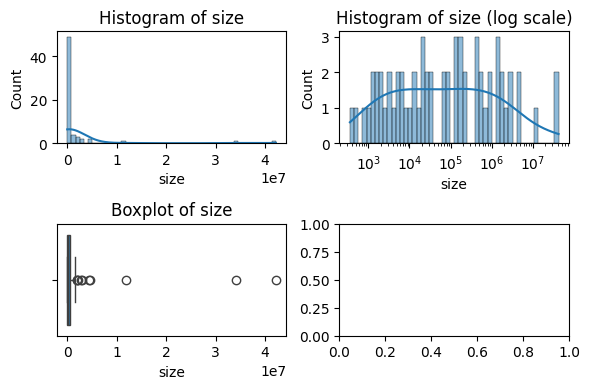

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(6, 4))

sns.histplot(df['size'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram of size')

sns.histplot(df['size'], bins=50, log_scale=True, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Histogram of size (log scale)')

# 3. Boxplot to spot outliers
sns.boxplot(x=df['size'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of size')

plt.tight_layout()
plt.savefig('size_distribution.png', dpi=300)
plt.show()

## Disambiguate Families 

In [22]:
PLATFORM_SUFFIX_RE = re.compile(
    r'(-|__)(win32|darwin|linux|freebsd|openbsd|netbsd|sunos|aix|android)'
    r'(-(x64|ia32|arm64|arm|mips64el|ppc64|s390x|riscv64|loong64|universal))?'
    r'(-(gnu|musl|msvc))?$'
)

def assign_family(path) -> str:
    """Collapse platform-specific builds of the same package into one family.
    e.g. '@esbuild__linux-x64--linux-x64-0.28.0' -> family '@esbuild'
         'lodash--lodash-4.17.21'                -> family 'lodash' (unchanged)
    """
    pkg_part = path.split('--')[0]
    return PLATFORM_SUFFIX_RE.sub('', pkg_part)
 
df['family'] = df['name'].apply(assign_family)
df['log_size'] = np.log10(df['size'])
df

,name,size,key,family,log_size
0,npm/@rollup__plugin-node-resolve--plugin-node-...,39973,@rollup__plugin-node-resolve--plugin-node-reso...,npm/@rollup__plugin-node-resolve,4.601767
1,npm/@svgr__plugin-svgo--plugin-svgo-8.1.0.tgz,3470,@svgr__plugin-svgo--plugin-svgo-8.1.0,npm/@svgr__plugin-svgo,3.540329
2,npm/ssri--ssri-14.0.0.tgz,11591,ssri--ssri-14.0.0,npm/ssri,4.064121
3,npm/object-copy--object-copy-1.0.0.tgz,3461,object-copy--object-copy-1.0.0,npm/object-copy,3.539202
4,npm/dir-glob--dir-glob-3.0.1.tgz,2258,dir-glob--dir-glob-3.0.1,npm/dir-glob,3.353724
...,...,...,...,...,...
2495,npm/xmlhttprequest-ssl--xmlhttprequest-ssl-4.0...,13703,xmlhttprequest-ssl--xmlhttprequest-ssl-4.0.0,npm/xmlhttprequest-ssl,4.136816
2496,npm/typed-array-byte-offset--typed-array-byte-...,6633,typed-array-byte-offset--typed-array-byte-offs...,npm/typed-array-byte-offset,3.821710
2497,npm/external-editor--external-editor-3.1.0.tgz,6645,external-editor--external-editor-3.1.0,npm/external-editor,3.822495
2498,npm/brorand--brorand-1.1.0.tgz,2509,brorand--brorand-1.1.0,npm/brorand,3.399501


## Partitioning

In [23]:
# tertiles
p33, p66 = df['log_size'].quantile([0.33, 0.66])
df['size_tier'] = pd.cut(df['log_size'], bins=[-float('inf'), p33, p66, float('inf')],
                          labels=['small', 'medium', 'large'])
df.head()

,name,size,key,family,log_size,size_tier
0,npm/@rollup__plugin-node-resolve--plugin-node-...,39973,@rollup__plugin-node-resolve--plugin-node-reso...,npm/@rollup__plugin-node-resolve,4.601767,large
1,npm/@svgr__plugin-svgo--plugin-svgo-8.1.0.tgz,3470,@svgr__plugin-svgo--plugin-svgo-8.1.0,npm/@svgr__plugin-svgo,3.540329,small
2,npm/ssri--ssri-14.0.0.tgz,11591,ssri--ssri-14.0.0,npm/ssri,4.064121,large
3,npm/object-copy--object-copy-1.0.0.tgz,3461,object-copy--object-copy-1.0.0,npm/object-copy,3.539202,small
4,npm/dir-glob--dir-glob-3.0.1.tgz,2258,dir-glob--dir-glob-3.0.1,npm/dir-glob,3.353724,small


In [25]:
# One representative per family
parts = []
for _, g in df.groupby('family'):
    parts.append(g.sample(1, random_state=42))
dedup = pd.concat(parts)

## Equal-width bins in log-size space
edges = np.linspace(
    dedup['log_size'].min(), dedup['log_size'].max() + 1e-9, 8 + 1
)
dedup.to_csv('dedup.csv', index=False)
#
#dedup = dedup.copy()
#dedup['bin'] = pd.cut(dedup['log_size'], bins=edges, labels=False, include_lowest=True)
#
#parts = []
#for _, g in dedup.groupby('bin'):
#    print(len(g))
#    # parts.append(g.sample(n=min(4, len(g)), random_state=42))
#    parts.append(g.sample(n=20, random_state=42))
#sample = pd.concat(parts)
#
##sample = sample.sort_values('size').reset_index(drop=True)
## sample = sample.sort_values('_key').reset_index(drop=True)
#sample = sample.sort_values('size').reset_index(drop=True)
#sample

## How many packages per block do I actually need to run?

In [12]:
from statsmodels.stats.power import FTestAnovaPower

k = 5          # number of algorithms
f = 0.25
alpha = 0.05
power = 0.8

analysis = FTestAnovaPower()
n_per_group = analysis.solve_power(effect_size=f, k_groups=k, alpha=alpha, power=power)
print(n_per_group)

195.7669964126193


In [13]:
# Adjusted for repeated measurements
rho = 0.7
n_blocked = n_per_group * (1 - rho)
print(n_blocked)

58.7300989237858
